<a href="https://colab.research.google.com/github/SeenaTS1999/Cognifyze_intenship/blob/main/Level_1_Tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv('Dataset .csv')
print("Rows, Columns:", data.shape)
data.info()


Rows, Columns: (9551, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 


In [ ]:
print("Missing values:")
print(data.isnull().sum()[data.isnull().sum() > 0])
# 9 Cuisines are null fill the null value
data['Cuisines'] = data['Cuisines'].fillna('Not Specified')
print("Remaining nulls:", data['Cuisines'].isnull().sum())

Missing values:
Cuisines    9
dtype: int64
Remaining nulls: 0


count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64


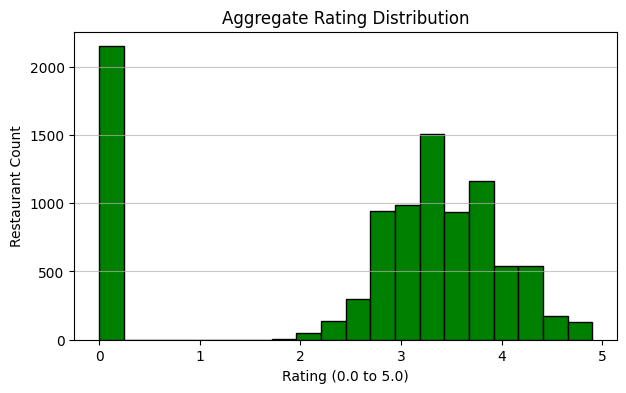

Restaurants with 0.0 rating: 2148 (22.49%)


In [ ]:
print(data['Aggregate rating'].describe())
plt.figure(figsize=(7, 4))
plt.hist(data['Aggregate rating'], bins=20, edgecolor='black', color='Green')
plt.title('Aggregate Rating Distribution')
plt.xlabel('Rating (0.0 to 5.0)')
plt.ylabel('Restaurant Count')
plt.grid(axis='y',alpha=0.7)
plt.show()

unrated_count = (data['Aggregate rating'] == 0.0).sum()
print(f"Restaurants with 0.0 rating: {unrated_count} ({(unrated_count / len(data))*100:.2f}%)")

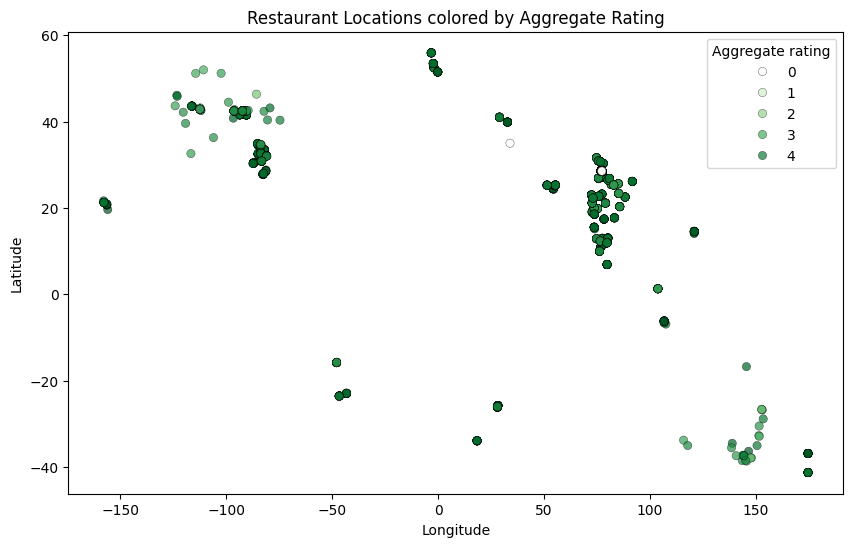

Correlation Matrix:
                   Latitude  Longitude  Aggregate rating
Latitude          1.000000  -0.200034         -0.124381
Longitude        -0.200034   1.000000         -0.206468
Aggregate rating -0.124381  -0.206468          1.000000


In [15]:


# Filter out 0 coordinates
geo_df = data[(data['Latitude']!= 0) & (data['Longitude']!= 0)]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=geo_df,
    x='Longitude',
    y='Latitude',
    hue='Aggregate rating',
    palette='Greens',
    alpha=0.7,
    edgecolor='black',
    linewidth=0.3)
plt.title('Restaurant Locations colored by Aggregate Rating')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

coord_corr = geo_df[['Latitude', 'Longitude', 'Aggregate rating']].corr()
print("Correlation Matrix:\n", coord_corr)